In [2]:
# --- STEP 1: IMPORT STUFF ---
# get the tools we need for data and the model
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- STEP 2: LOAD DATA ---
# read the file. use ';' because the file is not normal csv
df = pd.read_csv('cardio_train.csv', sep=';')

# --- STEP 3: FIX THE DATA (CLEANING) ---
# age is in days, so change it to years to understand better
df['age'] = (df['age'] / 365).round().astype(int)

# blood pressure has some crazy high and low numbers (outliers)
# we only keep the normal human range and fix errors
df = df[(df['ap_hi'] <= 250) & (df['ap_hi'] >= 60)]
df = df[(df['ap_lo'] <= 150) & (df['ap_lo'] >= 40)]
# systolic pressure must be higher than diastolic, so remove if wrong
df = df[df['ap_hi'] >= df['ap_lo']]

# --- STEP 4: REMOVE USELESS STUFF ---
# 'id' is just a number, it doesn't help to predict disease. delete it.
df.drop('id', axis=1, inplace=True)

# check how many rows left and see the table
print("Data cleaning complete. Current shape:", df.shape)
df.head()

Data cleaning complete. Current shape: (68669, 12)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,48,1,156,56.0,100,60,1,1,0,0,0,0


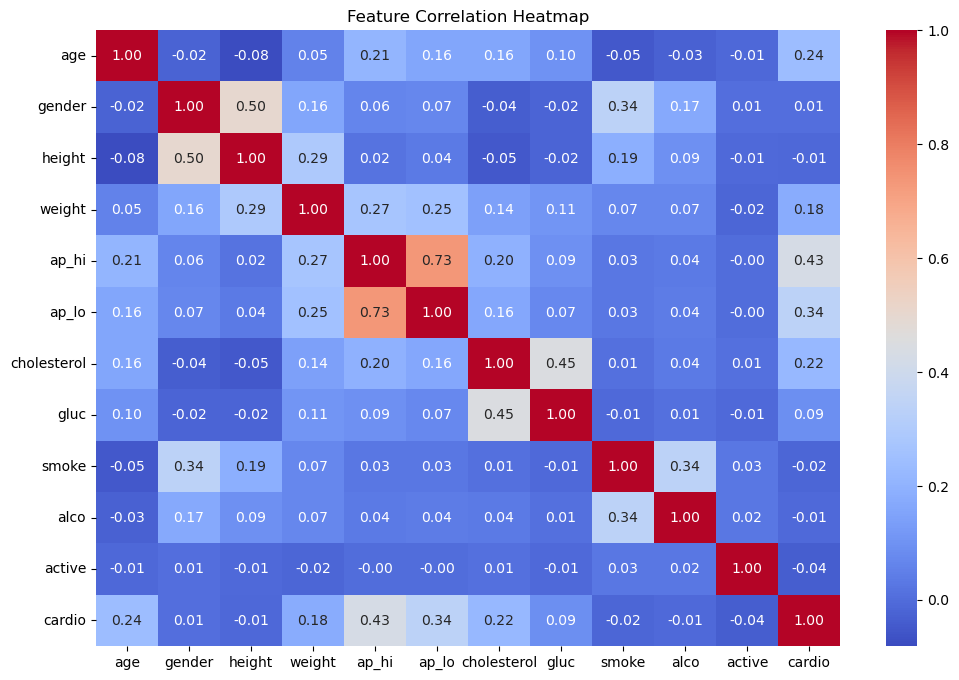

In [3]:
# --- STEP 5: DRAWING THE HEATMAP ---
# make the graph size big so we can read the numbers
plt.figure(figsize=(12, 8))

# draw the correlation map. 
# 'annot=True' shows the numbers, 'coolwarm' shows red for high and blue for low
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

# put a title on top
plt.title('Feature Correlation Heatmap')

# show the plot
plt.show()

In [4]:
# --- STEP 6: SEPARATE INPUTS AND ANSWERS ---
# X has all the symptoms like age, bp, weight. we remove 'cardio' here
X = df.drop('cardio', axis=1)

# y only has the 'cardio' column (the answer we want to predict)
y = df['cardio']

# --- STEP 7: SPLIT THE DATA ---
# 80% of data to train the model, 20% to test if it's correct later
# 'random_state=42' just makes sure the split is the same every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 8: SCALE THE DATA (IMPORTANT!) ---
# Logistic Regression needs numbers to be in same range
scaler = StandardScaler()

# make the train and test data have mean 0 and standard deviation 1
# this way big numbers like 'weight' don't confuse the model math
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully!")

Data split and scaled successfully!


In [5]:
# --- STEP 9: MAKE AND TRAIN THE MODEL ---
# initialize the Logistic Regression model [cite: 10]
model = LogisticRegression()

# the model 'learns' from the training data 
model.fit(X_train_scaled, y_train)

# --- STEP 10: TEST THE BRAIN ---
# make the model guess the answers for the test set
y_pred = model.predict(X_test_scaled)

# --- STEP 11: SEE HOW WE DID ---
# print the accuracy to compare with other team members [cite: 21]
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# classification report shows precision and recall for the medical report 
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.7332896461336829

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6960
           1       0.76      0.67      0.71      6774

    accuracy                           0.73     13734
   macro avg       0.74      0.73      0.73     13734
weighted avg       0.74      0.73      0.73     13734



In [6]:
# --- STEP 12: FEATURE ENGINEERING (ADD BMI) ---
# create BMI because it is a better medical indicator than just weight 
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# --- STEP 13: FIX CATEGORIES (ONE-HOT ENCODING) ---
# change cholesterol and glucose (1,2,3) into separate yes/no columns
# this helps the model math not get confused by rankings
df = pd.get_dummies(df, columns=['cholesterol', 'gluc'], prefix=['chol', 'gluc'])

In [7]:
# --- STEP 14: RE-DO SPLIT AND SCALE ---
# we have new columns, so we must split and scale again
X = df.drop('cardio', axis=1)
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- STEP 15: HYPERPARAMETER TUNING ---
# try to make the model smarter using C=0.1 and liblinear solver 
tuned_model = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000)
tuned_model.fit(X_train_scaled, y_train)

# --- STEP 16: FINAL RESULTS ---
# get new results to see if the changes helped the accuracy [cite: 21]
y_pred_new = tuned_model.predict(X_test_scaled)
print("New Accuracy Score:", accuracy_score(y_test, y_pred_new))
print("\nNew Classification Report:\n", classification_report(y_test, y_pred_new))

New Accuracy Score: 0.7335080821319353

New Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6960
           1       0.76      0.67      0.71      6774

    accuracy                           0.73     13734
   macro avg       0.74      0.73      0.73     13734
weighted avg       0.74      0.73      0.73     13734



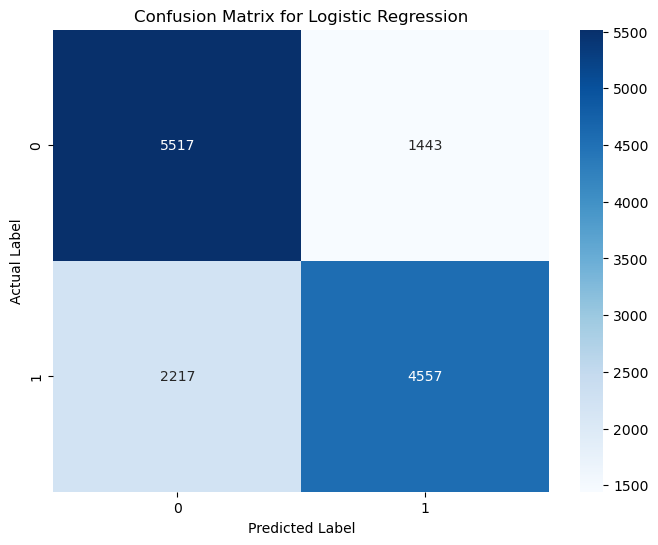

In [10]:
# --- STEP 17: CONFUSION MATRIX VISUALIZATION ---
# calculate the matrix
cm = confusion_matrix(y_test, y_pred_new)

# make it look nice with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# add labels so people know what is what
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Logistic Regression')

# SAVE THE IMAGE HERE
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

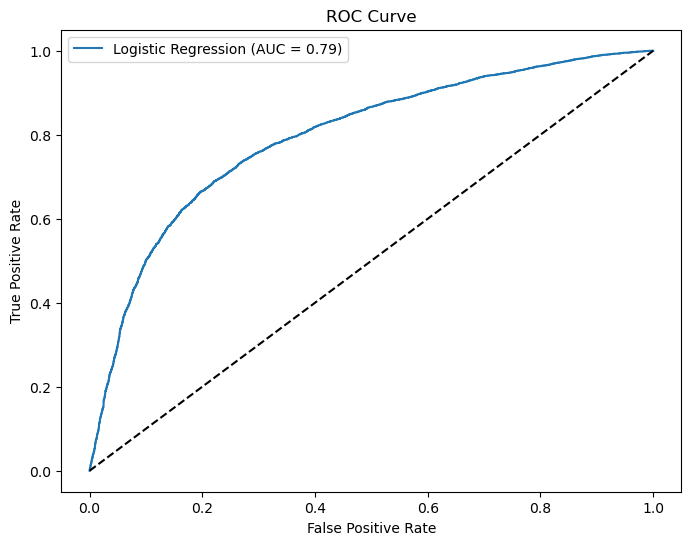

The AUC Score is: 0.7948


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# --- STEP 18: ROC CURVE AND AUC ---
# get the probability scores from the model
y_prob = tuned_model.predict_proba(X_test_scaled)[:, 1]

# calculate the curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# plot the graph
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# SAVE THE IMAGE HERE
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')

plt.show()

print(f"The AUC Score is: {auc_score:.4f}")